In [1]:
# !pip install torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
BATCH_SIZE = 64

data_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root = "./data", train = True, transform = data_transform, download = True)

train_loader = DataLoader(train_dataset ,  batch_size = BATCH_SIZE, shuffle = True)

100%|██████████| 9.91M/9.91M [00:19<00:00, 500kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 90.8kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 240kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.53MB/s]


In [5]:
#Define Auto encoder

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        #Encoder

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
            nn.ReLU(),
        )

        #Decoder

        self.decoder  = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 784),
            nn.Sigmoid()

        )


    def forward(self, x):

        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [8]:
latent_dim = 64
hidden_dim = 256

#Defining the model, loss

model = AutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [9]:
epochs = 5

model.train()

for epoch in range(epochs):
    total_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()

        x_recon = model(x)

        loss = criterion(x_recon, x)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

Epoch 1/5, Loss: 0.03218657828903179
Epoch 2/5, Loss: 0.01253865475454596
Epoch 3/5, Loss: 0.00941469508068346
Epoch 4/5, Loss: 0.007974969202291165
Epoch 5/5, Loss: 0.007000921269767543


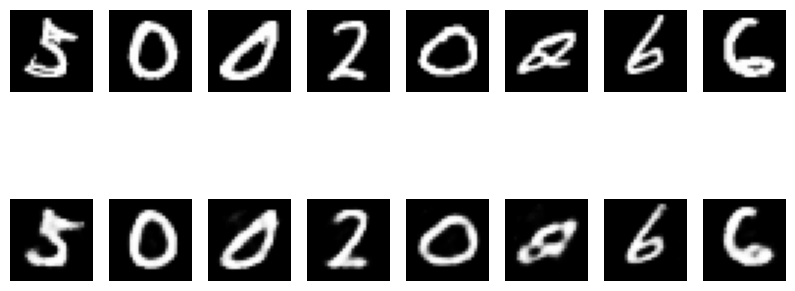

In [12]:
model.eval()

with torch.no_grad():

    x, _ = next(iter(train_loader))

    x = x.view(-1, 784).to(device)

    x_recon = model(x)

    # x = x.cpu()

    n = 8
    plt.figure(figsize = (10, 4.5))

    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(x[i].reshape(28, 28).cpu().numpy(), cmap = "gray")
        plt.axis("off")

        plt.subplot(2, n, i+1+n)
        plt.imshow(x_recon[i].reshape(28, 28).cpu().numpy(), cmap = "gray")
        plt.axis("off")

    plt.show()

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def visualize_latent_space(model, dataloader, device):
    model.eval()

    latents = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.view(x.size(0), -1).to(device)

            z = model.encoder(x)

            latents.append(z.cpu())
            labels.append(y)

    latents = torch.cat(latents, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()

    latent_dim = latents.shape[1]

    print(f"Latent Shape: {latents.shape}")

    # --------------------------------------------------
    # 1D Latent Space
    # --------------------------------------------------
    if latent_dim == 1:
        plt.figure(figsize=(8, 5))

        plt.hist(
            latents[:, 0],
            bins=50,
            alpha=0.8,
            edgecolor="black"
        )

        plt.title("1D Latent Distribution")
        plt.xlabel("Latent Value")
        plt.ylabel("Frequency")
        plt.show()

    # 2D Latent Space

    elif latent_dim == 2:
        plt.figure(figsize=(8, 6))

        scatter = plt.scatter(
            latents[:, 0],
            latents[:, 1],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.7
        )

        plt.colorbar(scatter)
        plt.title("2D Latent Space")
        plt.xlabel("z1")
        plt.ylabel("z2")
        plt.show()

    # 3D Latent Space

    elif latent_dim == 3:
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection="3d")

        scatter = ax.scatter(
            latents[:, 0],
            latents[:, 1],
            latents[:, 2],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.7
        )

        fig.colorbar(scatter)

        ax.set_title("3D Latent Space")
        ax.set_xlabel("z1")
        ax.set_ylabel("z2")
        ax.set_zlabel("z3")

        plt.show()

    # Higher Dimensions -> PCA -> 2D

    else:
        print(
            f"Latent dimension is {latent_dim}. "
            "Applying PCA → 2D..."
        )

        pca = PCA(n_components=2)
        latents_2d = pca.fit_transform(latents)

        explained = pca.explained_variance_ratio_.sum()

        plt.figure(figsize=(8, 6))

        scatter = plt.scatter(
            latents_2d[:, 0],
            latents_2d[:, 1],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.7
        )

        plt.colorbar(scatter)

        plt.title(
            f"PCA Projection of Latent Space\n"
            f"Explained Variance: {explained:.2%}"
        )

        plt.xlabel("PC1")
        plt.ylabel("PC2")

        plt.show()

Latent Shape: (60000, 64)
Latent dimension is 64. Applying PCA → 2D...


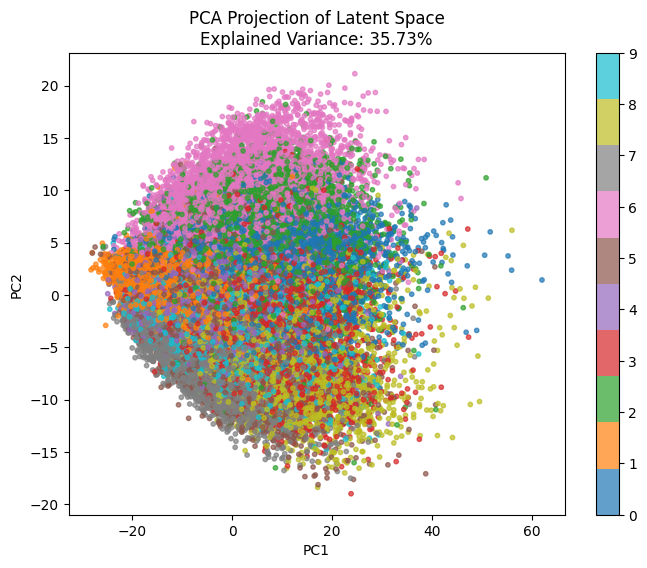

In [14]:
visualize_latent_space(
    model,
    train_loader,
    device
)

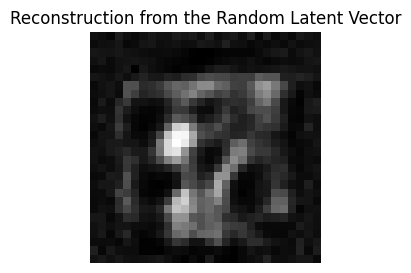

In [15]:
model.eval()

with torch.no_grad():

    latent_dim = model.encoder[-2].out_features
    z_random = torch.randn(1, latent_dim).to(device)

    x_generated = model.decoder(z_random)

    x_generated = x_generated.cpu().view(28, 28)

plt.figure(figsize = (3,3))
plt.imshow(x_generated, cmap = "gray")
plt.axis('off')
plt.title('Reconstruction from the Random Latent Vector')
plt.show()